# Meausure energy-energy correlators with Omnifold measurement

This notebook implements a measurement of the two-point energy correlator observable (EEC) using the ATLAS Omnifold Z+jets measurement. The observable is first examined using the "pseudo-measurement" and statistical agreement with the target truth pseudodata distribution is checked. Then the results of the measurement on data are presented.

Note given that re-calculating the energy products and angular coordinates of track pairs is relatively inexpensive once parallelized, this notebook does not pre-compute these results and write them to disk. Instead the histogramming is the compute expensive step. For better performance, both steps are parallelized using dask delayed. See `eec_utils.py` for details.

This notebook takes approximately XXX minutes to run on a CPU node on the Perlmutter supercomputer.

## Preliminaries: load all data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import pickle
import numpy as np
import awkward as ak
import uproot
import pandas as pd
import dask.distributed as distributed

import eec_utils as eec
import visualize as vis

In [3]:
# Get ROOT TTrees and pass 190 flags
mg_mc_path = "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_May19_MGPy8FxFxPlusNonStrong_withdd_Test_23Nov25_shuffled.root"
f = uproot.open(mg_mc_path)
t = f["OmniTree"]
truth_pass190 = ak.to_numpy(t["truth_pass190"].array())
truth_pT_ll = ak.to_numpy(t["truth_pT_ll"].array())
truth_pass200 = np.logical_and(truth_pass190, truth_pT_ll > 200)

truth_pd_path = "/pscratch/sd/k/kgreif/data/TruthPseudodata_Sherpa2211DY_Dibo_EW_PowhegPythiaTop_PosWeights_WithTracks_June2025_shuffled.root"
f_pd = uproot.open(truth_pd_path)
t_pd = f_pd["OmniTree"]
truth_pass190_pd = ak.to_numpy(t_pd["truth_pass190"].array())
truth_pT_ll_pd = ak.to_numpy(t_pd["truth_pT_ll"].array())
truth_pass200_pd = np.logical_and(truth_pass190_pd, truth_pT_ll_pd > 200)

hv_mc_path = "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_Mar10_Sherpa2211_LookLike_MgFxFx_Test_V5_shuffled.root"
f_hv = uproot.open(hv_mc_path)
t_hv = f_hv["OmniTree"]
truth_pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())
truth_pT_ll_hv = ak.to_numpy(t_hv["truth_pT_ll"].array())
truth_pass200_hv = np.logical_and(truth_pass190_hv, truth_pT_ll_hv > 200)

sherpa_mc_path = "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_30Jul2025_Sherpa2211PlusNonStrong_8Dec25_shuffled.root"
f_sherpa = uproot.open(sherpa_mc_path)
t_sherpa = f_sherpa["OmniTree"]
truth_pass190_sherpa = ak.to_numpy(t_sherpa["truth_pass190"].array())
truth_pT_ll_sherpa = ak.to_numpy(t_sherpa["truth_pT_ll"].array())
truth_pass200_sherpa = np.logical_and(truth_pass190_sherpa, truth_pT_ll_sherpa > 200)

In [4]:
# Load event weights for the Sherpa and MadGraph predictions
mg_weights = np.load("/pscratch/sd/k/kgreif/zjets_plot_staging/madgraph_weights.npz")
sherpa_weights = np.load("/pscratch/sd/k/kgreif/zjets_plot_staging/sherpa_weights.npz")

## Measurement with Pseudodata

In [5]:
# Load all weights from the Omnifold pseudodata measurement
of_pseudodata = pd.read_hdf(
    "../weight_storage/zjets-v4/pd-weights.h5",
    key="weights",
    mode="r",
)
of_pseudodata_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/pd-weights.h5",
    key="hv_weights",
    mode="r",
)

In [6]:
# Create dictionary describing all of the histograms needed for the pseudodata measurement
n_init_weights = [name for name in of_pseudodata.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in of_pseudodata.keys() if "weights_bootstrap_mc_" in name]
truth_mc_weights = {
    "prior": mg_weights["nominal"][truth_pass200 == 1],
    "nominal": of_pseudodata["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{f"ensemble_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": of_pseudodata[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": of_pseudodata["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": of_pseudodata["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_pseudodata["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_pseudodata["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": of_pseudodata["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_pseudodata["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_pseudodata["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    "muCalScale": of_pseudodata["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_pseudodata["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_pseudodata["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_pseudodata["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_pseudodata["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    "pileup": of_pseudodata["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_pseudodata["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_pseudodata["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_pseudodata["target_dd"].to_numpy()[truth_pass200 == 1],
}
truth_pd_weights = {
    "truthpd": ak.to_numpy(t_pd["weight_mc"].array())[truth_pass200_pd == 1],
}
hv_weights = {
    "hv": of_pseudodata_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1],
}

In [7]:
bins = np.logspace(-6, -1, 30)
print(bins)

[1.00000000e-06 1.48735211e-06 2.21221629e-06 3.29034456e-06
 4.89390092e-06 7.27895384e-06 1.08263673e-05 1.61026203e-05
 2.39502662e-05 3.56224789e-05 5.29831691e-05 7.88046282e-05
 1.17210230e-04 1.74332882e-04 2.59294380e-04 3.85662042e-04
 5.73615251e-04 8.53167852e-04 1.26896100e-03 1.88739182e-03
 2.80721620e-03 4.17531894e-03 6.21016942e-03 9.23670857e-03
 1.37382380e-02 2.04335972e-02 3.03919538e-02 4.52035366e-02
 6.72335754e-02 1.00000000e-01]


In [8]:
# Run computations with dask
cluster = distributed.LocalCluster(
    n_workers=100,
    threads_per_worker=2,
    memory_limit="auto",
)
client = distributed.Client(cluster)

print("Histogramming Madgraph MC sample")
truth_mc_hists = eec.run_eec_workflow_parallel(
    mg_mc_path,
    "OmniTree",
    truth_pass200,
    truth_mc_weights,
    bins,
    get_truth=True,
    chunk_size=1000,
)
print("Histogramming HV sample")
truth_hv_hists = eec.run_eec_workflow_parallel(
    hv_mc_path,
    "OmniTree",
    truth_pass200_hv,
    hv_weights,
    bins,
    get_truth=True,
    chunk_size=1000,
)
print("Histogramming Truth Pseudodata sample")
truth_pd_hists = eec.run_eec_workflow_parallel(
    truth_pd_path,
    "OmniTree",
    truth_pass200_pd,
    truth_pd_weights,
    bins,
    get_truth=True,
    chunk_size=1000,
    max_events=5000000,
)

client.close()
cluster.close()

Histogramming Madgraph MC sample


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 744.29 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Histogramming HV sample
Histogramming Truth Pseudodata sample


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 23.05 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [13]:
# Pickle the resulting histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "pd_eec_hists.pkl"), "wb") as f:
    pickle.dump(
        {
            "truth_mc": truth_mc_hists,
            "truth_hv": truth_hv_hists,
            "truth_pd": truth_pd_hists,
        },
        f,
    )

### Plotting

In [26]:
# Load the histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "pd_eec_hists.pkl"), "rb") as f:
    all_hists = pickle.load(f)

measurement_hists = {**all_hists["truth_mc"], **all_hists["truth_hv"]}
truth_pd_hists = all_hists["truth_pd"]

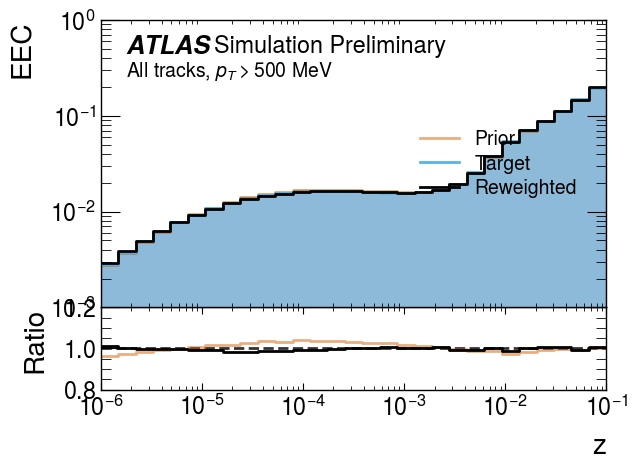

In [27]:
# Plot comparison to truth pseudodata (no uncertainties)
import visualize as vis
comp = vis.compare_to_target(
    measurement_hists,
    truth_pd_hists,
    log_xscale=True,
    linear_yscale=False,
    ylabel="EEC",
    xlabel="z",
    normalize=True,
    rlab="All tracks, $p_T > 500$ MeV",
)

Chi-squared test: dof=29, χ²=15.79143, p-value=0.9778


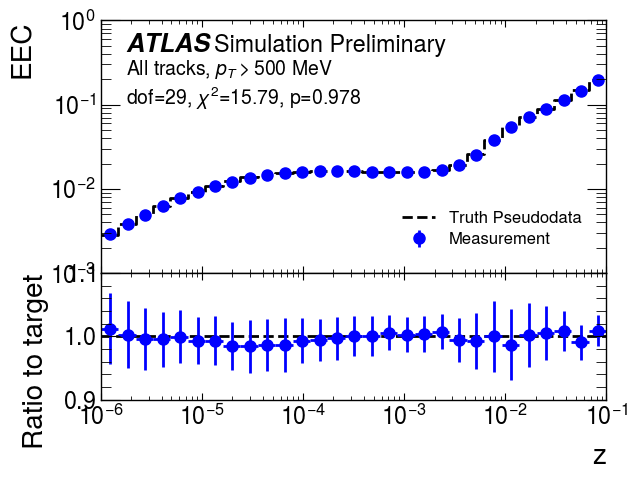

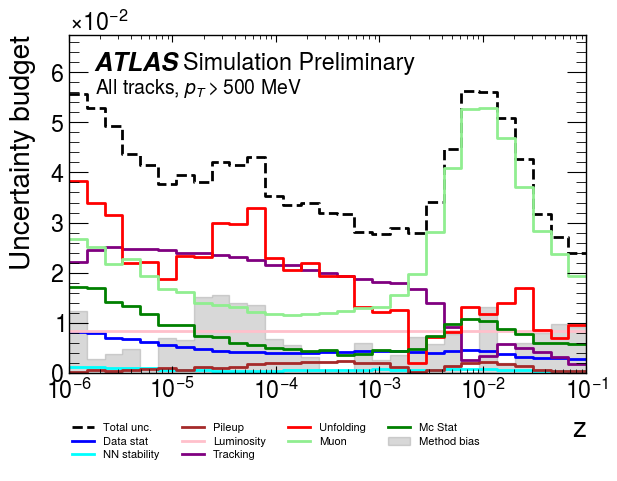

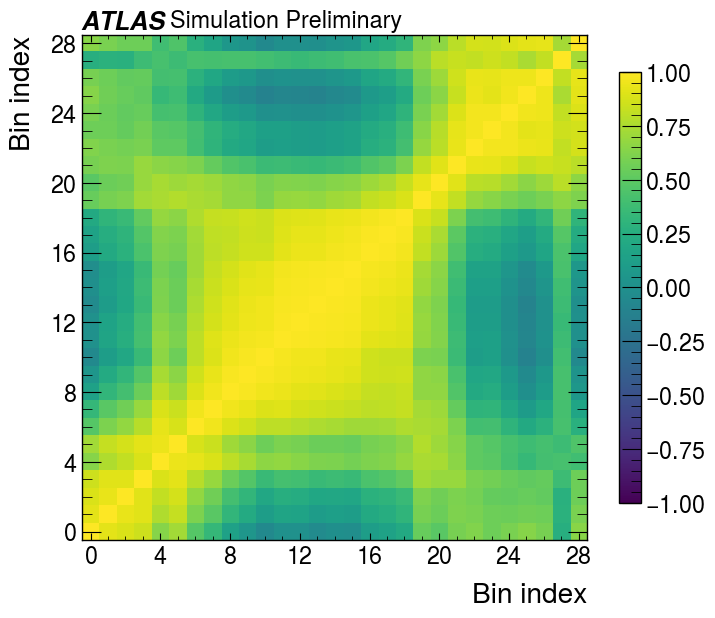

In [28]:
# Plot pseudo-measurement and uncertainty budget
import visualize as vis

xsec, budget, cov = vis.plot_measurement_with_uncertainties(
    measurement_hists,
    truth_pd_hists,
    figsize=(6.4, 4.8),
    color="blue",
    linear_yscale=False,
    ylabel="EEC",
    xlabel="z",
    normalize=True,
    llab="Simulation Preliminary",
    rlab="All tracks, $p_T > 500$ MeV",
    simple_corr_labels=True,
    do_chi2_test=True,
    ylim=(1e-3, 1e0),
)
xsec.show()
budget.show()
cov.show()

## Measurement with data

In [5]:
# Load all weights from the Omnifold data measurement
of_data = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="weights",
    mode="r",
)
of_data_hv = pd.read_hdf(
    "../weight_storage/zjets-v4/data-weights.h5",
    key="hv_weights",
    mode="r",
)

In [6]:
# Create dictionary describing all of the histograms needed for the data measurement
n_init_weights = [name for name in of_data.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [
    name for name in of_data.keys() if "weights_bootstrap_data_" in name
]
mcbootstrap_weights = [
    name for name in of_data.keys() if "weights_bootstrap_mc_" in name
]
truth_mc_weights = {
    "nominal": of_data["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{
        f"ensemble_{i}": of_data[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(n_init_weights)
    },
    **{
        f"bootstrap_data_{i}": of_data[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(dbootstrap_weights)
    },
    **{
        f"bootstrap_mc_{i}": of_data[name].to_numpy()[truth_pass200 == 1]
        for i, name in enumerate(mcbootstrap_weights)
    },
    "trackEffMain": of_data["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": of_data["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": of_data["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": of_data["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": of_data["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": of_data["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": of_data["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    "muCalScale": of_data["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": of_data["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": of_data["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": of_data["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": of_data["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    "pileup": of_data["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": of_data["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": of_data["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": of_data["target_dd"].to_numpy()[truth_pass200 == 1],
}
hv_weights = {
    "hv": of_data_hv["weights_hv"].to_numpy()[truth_pass200_hv == 1],
}
truth_madgraph_weights = {
    "madgraph": mg_weights["nominal"][truth_pass200 == 1],
    "weights_theoryQCD": mg_weights["weights_theoryQCD"][truth_pass200 == 1],
    "weights_theoryPDF": mg_weights["weights_theoryPDF"][truth_pass200 == 1],
    "weights_theoryAlphaS": mg_weights["weights_theoryAlphaS"][truth_pass200 == 1],
    "weights_theoryPSsoft": mg_weights["weights_theoryPSsoft"][truth_pass200 == 1],
    "weights_theoryPSjet": mg_weights["weights_theoryPSjet"][truth_pass200 == 1],
    "weights_theoryPSscale": mg_weights["weights_theoryPSscale"][truth_pass200 == 1],
    "weights_theoryMPI": mg_weights["weights_theoryMPI"][truth_pass200 == 1],
}
truth_sherpa_weights = {
    "sherpa": sherpa_weights["nominal"][truth_pass200_sherpa == 1],
    "weights_theoryQCD": sherpa_weights["weights_theoryQCD"][truth_pass200_sherpa == 1],
    "weights_theoryPDF": sherpa_weights["weights_theoryPDF"][truth_pass200_sherpa == 1],
    "weights_theoryAlphaS": sherpa_weights["weights_theoryAlphaS"][
        truth_pass200_sherpa == 1
    ],
}

In [7]:
bins = np.logspace(-6, -1, 30)
print(bins)

[1.00000000e-06 1.48735211e-06 2.21221629e-06 3.29034456e-06
 4.89390092e-06 7.27895384e-06 1.08263673e-05 1.61026203e-05
 2.39502662e-05 3.56224789e-05 5.29831691e-05 7.88046282e-05
 1.17210230e-04 1.74332882e-04 2.59294380e-04 3.85662042e-04
 5.73615251e-04 8.53167852e-04 1.26896100e-03 1.88739182e-03
 2.80721620e-03 4.17531894e-03 6.21016942e-03 9.23670857e-03
 1.37382380e-02 2.04335972e-02 3.03919538e-02 4.52035366e-02
 6.72335754e-02 1.00000000e-01]


In [8]:
# Run computations with dask
n_cores = os.cpu_count()
cluster = distributed.LocalCluster(
    n_workers=100,
    threads_per_worker=2,
    memory_limit="auto",
)
client = distributed.Client(cluster)

# Histogram the Madgraph MC sample
print("Histogramming Madgraph MC sample")
truth_mc_hists = eec.run_eec_workflow_parallel(
    mg_mc_path,
    "OmniTree",
    truth_pass200,
    truth_mc_weights,
    bins,
    get_truth=True,
    chunk_size=1000,
)
print("Histogramming HV sample")
truth_hv_hists = eec.run_eec_workflow_parallel(
    hv_mc_path,
    "OmniTree",
    truth_pass200_hv,
    hv_weights,
    bins,
    get_truth=True,
    chunk_size=1000,
)
print("Histogramming Madgraph prediction")
truth_madgraph_hists = eec.run_eec_workflow_parallel(
    mg_mc_path,
    "OmniTree",
    truth_pass200,
    truth_madgraph_weights,
    bins,
    get_truth=True,
    chunk_size=1000,
)
print("Histogramming Sherpa prediction")
truth_sherpa_hists = eec.run_eec_workflow_parallel(
    sherpa_mc_path,
    "OmniTree",
    truth_pass200_sherpa,
    truth_sherpa_weights,
    bins,
    get_truth=True,
    chunk_size=1000,
    max_events=5000000,
)

client.close()
cluster.close()

Histogramming Madgraph MC sample


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 740.08 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Histogramming HV sample
Histogramming Madgraph prediction


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 34.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Histogramming Sherpa prediction


/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 62.71 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-01-19 20:51:53,800 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  Fil

In [17]:
# Pickle the resulting histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "data_eec_hists.pkl"), "wb") as f:
    pickle.dump(
        {
            "truth_mc": truth_mc_hists,
            "truth_hv": truth_hv_hists,
            "truth_madgraph": truth_madgraph_hists,
            "truth_sherpa": truth_sherpa_hists,
        },
        f,
    )

## Plotting

In [21]:
# Load the histograms
hist_dir = "./hist_storage"
with open(os.path.join(hist_dir, "data_eec_hists.pkl"), "rb") as f:
    all_hists = pickle.load(f)

measurement_hists = {**all_hists["truth_mc"], **all_hists["truth_hv"]}
truth_madgraph_hists = all_hists["truth_madgraph"]
truth_sherpa_hists = all_hists["truth_sherpa"]

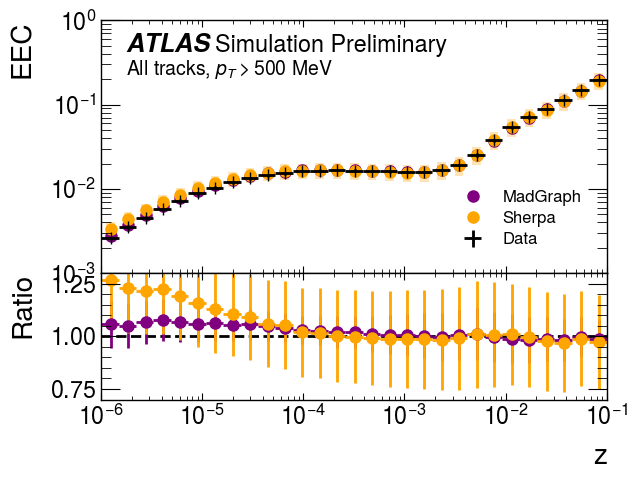

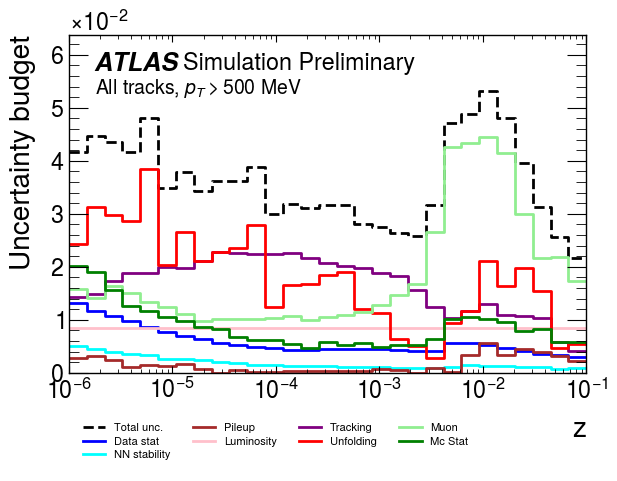

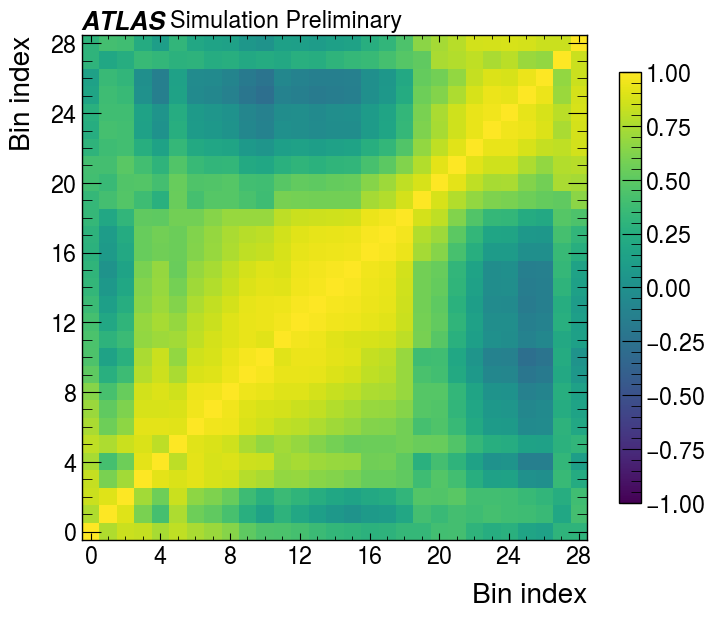

In [24]:
# Plot data measurement and uncertainty budget
xsec, budget, cov = vis.plot_measurement_with_uncertainties(
    measurement_hists,
    truth_madgraph_hists,
    truth_sherpa_hists,
    measured_label="Data",
    target_key="madgraph",
    target_label="MadGraph",
    target2_key="sherpa",
    target2_label="Sherpa",
    data_measurement_mode=True,
    color="black",
    linear_yscale=False,
    ylabel="EEC",
    xlabel="z",
    normalize=True,
    rlab="All tracks, $p_T > 500$ MeV",
    ylim=(1e-3, 1e0),
    rlim=(0.7, 1.3),
    simple_corr_labels=True,
)
xsec.show()
budget.show()
cov.show()